# Phase 1 - Community Detection with Leiden

This notebook analyzes Leiden partitions before and after adding Bibliographic Coupling (BC) links, focusing on how BC changes modular structure within the same algorithmic lens.

| | G_CitOnly | G_BC |
|---|---|---|
| **Type** | Undirected, unweighted | Undirected, weighted (BC score) |
| **Edges** | Citation links only | Citations + bibliographic coupling |
| **CD input** | `graph_internal_2020.gpickle` | `graph_combined_2020.gpickle` |
| **Leiden variant** | `RBConfigurationVertexPartition` | `RBConfigurationVertexPartition` (w/ weights) |

Scope of this phase:
- build robust crisp partitions on both graphs via resolution sweep;
- quantify run stability through a multi-seed ensemble;
- characterize structural transformations (stable/merged/split/dissolved) after BC insertion;
- validate semantic consistency with FOS/SDG purity diagnostics;
- statistical validation of merge concentration via Gini permutation test (corpus-level null).

In [1]:
import os, re, time, pickle, textwrap, warnings
from collections import Counter, defaultdict
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import igraph as ig
import leidenalg
from sklearn.metrics import normalized_mutual_info_score, mutual_info_score
from scipy.stats import entropy as scipy_entropy

from cdlib import NodeClustering, evaluation
from pathlib import Path

BASE_DIR = Path().resolve().parent.parent
GRAPH_DIR = BASE_DIR / "data" / "graph"
INTERNAL_PATH = GRAPH_DIR / "graph_internal_2020.gpickle"
COMBINED_PATH = GRAPH_DIR / "graph_combined_2020.gpickle"

#create ./output directory if it doesn't exist
OUTPUT_DIR = Path().resolve() / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

N_RUN         = 100
TOP_N_COMMS   = 100
TOP_K         = 5
MIN_COMM_SIZE = 20

In [2]:
def load_graph(filepath: str):
    with open(filepath, 'rb') as fh:
        return pickle.load(fh)

G_CitOnly       = load_graph(INTERNAL_PATH)
G_BC            = load_graph(COMBINED_PATH)
G_CitOnly_undir = G_CitOnly.to_undirected()

w = [d['weight'] for _, _, d in G_BC.edges(data=True) if 'weight' in d]

print(f"G_CitOnly  {G_CitOnly.number_of_nodes():>7,} nodes  {G_CitOnly.number_of_edges():>8,} edges  (directed, unweighted)")
print(f"G_BC  {G_BC.number_of_nodes():>7,} nodes  {G_BC.number_of_edges():>8,} edges  "
      f"| weights: median={np.median(w):.3f}  range=[{min(w):.3f}, {max(w):.3f}]")

G_CitOnly   55,078 nodes   217,925 edges  (directed, unweighted)
G_BC   57,603 nodes   745,451 edges  | weights: median=0.338  range=[0.158, 1.000]


In [3]:
def _split_labels(raw_value):
    return [p.strip() for p in re.split(r';\s*', str(raw_value)) if p.strip()]

def _extract_l2(counter):
    l2 = Counter()
    for label, count in counter.items():
        if re.match(r'^\d{2}', label):
            l2[label[:2]] += count
    return l2

def compute_attr_stats(G, attributes=('FOS', 'SDG')):
    """Count labels per attribute; add 2-digit aggregation for FOS."""
    stats = {}
    for attr in attributes:
        counts = Counter()
        n_nodes = 0
        for _, data in G.nodes(data=True):
            val = data.get(attr)
            if not val:
                continue
            n_nodes += 1
            counts.update(_split_labels(val))
        stats[attr] = {'counts': counts, 'n_nodes': n_nodes}
        if attr == 'FOS':
            stats['FOS_L2'] = {'counts': _extract_l2(counts), 'n_nodes': n_nodes}
    return stats

def compare_attr_stats(stats_int, stats_comb, key):
    n_i = stats_int[key]['n_nodes']
    n_c = stats_comb[key]['n_nodes']
    all_labels = sorted(set(stats_int[key]['counts']) | set(stats_comb[key]['counts']))

    rows = []
    for label in all_labels:
        ci = stats_int[key]['counts'].get(label, 0)
        cc = stats_comb[key]['counts'].get(label, 0)
        rows.append({
            'label': label,
            'int_cnt': ci,  'int_pct': ci / n_i * 100 if n_i else 0,
            'comb_cnt': cc, 'comb_pct': cc / n_c * 100 if n_c else 0,
        })
    return pd.DataFrame(rows)

In [4]:


fos_stats_path = OUTPUT_DIR / 'leiden_FOS_stats.csv'
sdg_stats_path = OUTPUT_DIR / 'leiden_SDG_stats.csv'

s_int  = compute_attr_stats(G_CitOnly)
s_comb = compute_attr_stats(G_BC)

pd.concat([
    compare_attr_stats(s_int, s_comb, 'FOS').assign(level='detail'),
    compare_attr_stats(s_int, s_comb, 'FOS_L2').assign(level='L2'),
], ignore_index=True).to_csv(fos_stats_path, index=False)

compare_attr_stats(s_int, s_comb, 'SDG') \
    .sort_values('int_cnt', ascending=False) \
    .to_csv(sdg_stats_path, index=False)

print(f'{fos_stats_path.name}  {sdg_stats_path.name}  created')

leiden_FOS_stats.csv  leiden_SDG_stats.csv  created


## Leiden - Resolution-aware modularity optimization

Leiden (Traag et al., 2019) with `RBConfigurationVertexPartition` and explicit resolution parameter γ.
Standard `ModularityVertexPartition` has a known resolution limit (Fortunato & Barthélemy, 2007):
communities below ~√(2M) internal edges can be invisible. With 590k edges, that threshold is ~1086 —
a real risk given median community size = 2.

### Protocol
1. **Resolution sweep**: run ensemble across γ ∈ [0.01, 10] to find the plateau where community count is stable.
2. **Ensemble**: 100 runs per γ, medoid selection via pairwise NMI.
3. **Cache**: all results persist to `./output/` — rerun loads from disk.

### Interpretation
- high mean NMI and low std → robust community structure;
- a mild stability drop on `G_BC` → boundary reshaping due to BC, not structural collapse;
- stable modularity with fewer/larger communities → controlled de-fragmentation.

In [ ]:
"""
Leiden ensemble with resolution sweep + Gini permutation test.
- RBConfigurationVertexPartition with gamma sweep
- Medoid selection via pairwise NMI
- Permutation test for merge semantic significance (corpus-level null)
- Persistent cache in ./output
"""

import os
import re
import time
import pickle
import numpy as np
import igraph as ig
import networkx as nx
from collections import Counter
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor
from sklearn.metrics import normalized_mutual_info_score
from cdlib import NodeClustering, evaluation


# ──────────────────────────────────────────────
# Cache helpers
# ──────────────────────────────────────────────

def _safe_name(s):
    return re.sub(r'[^\w\-.]', '_', str(s))

def _cache_save(path, obj):
    with open(path, 'wb') as f:
        pickle.dump(obj, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"    Cached: {path}")

def _cache_load(path):
    with open(path, 'rb') as f:
        obj = pickle.load(f)
    print(f"    Loaded: {path}")
    return obj


# ──────────────────────────────────────────────
# NMI utilities
# ──────────────────────────────────────────────

def compute_nmi_matrix(labels_list, n_workers=15):
    n = len(labels_list)
    mat = np.eye(n)
    pairs = [(i, j) for i in range(n) for j in range(i + 1, n)]

    def _nmi(pair):
        i, j = pair
        return i, j, normalized_mutual_info_score(
            labels_list[i], labels_list[j], average_method='arithmetic'
        )

    with ThreadPoolExecutor(max_workers=n_workers) as pool:
        for i, j, v in pool.map(_nmi, pairs):
            mat[i, j] = mat[j, i] = v
    return mat


def select_medoid(nmi_matrix):
    n = nmi_matrix.shape[0]
    avg_nmi = (nmi_matrix.sum(axis=1) - 1.0) / (n - 1)
    return int(np.argmax(avg_nmi)), avg_nmi, nmi_matrix[np.triu_indices(n, k=1)]


# ──────────────────────────────────────────────
# Leiden worker
# ──────────────────────────────────────────────

def _run_single_leiden(args):
    seed, g_ig_pickled, n_nodes, weights, resolution = args
    import pickle, leidenalg
    import numpy as np

    G_ig = pickle.loads(g_ig_pickled)
    partition = leidenalg.find_partition(
        G_ig, leidenalg.RBConfigurationVertexPartition,
        weights=weights, seed=seed,
        resolution_parameter=resolution
    )

    labels = np.full(n_nodes, -1, dtype=np.int32)
    communities = []
    for cid, comm in enumerate(partition):
        communities.append(list(comm))
        for idx in comm:
            labels[idx] = cid

    return seed, labels, communities


# ──────────────────────────────────────────────
# Ensemble runner + cache
# ──────────────────────────────────────────────

def run_leiden_ensemble(G_nx, graph_name, weights=None, resolution=1.0,
                        n_runs=100, base_seed=1, n_workers=10,
                        cache_dir=OUTPUT_DIR, force=False):
    cache_file = os.path.join(
        cache_dir,
        f"leiden_{_safe_name(graph_name)}_g{resolution:.6f}_r{n_runs}.pkl"
    )
    if not force and os.path.exists(cache_file):
        cached = _cache_load(cache_file)
        clustering = NodeClustering(
            cached['medoid_communities'], graph=G_nx, method_name='leiden'
        )
        print(f"  Medoid #comms: {cached['stats']['medoid_n_communities']} | "
              f"Q: {cached['stats']['medoid_modularity']:.4f} | "
              f"NMI mean: {cached['stats']['nmi_mean']:.4f}")
        return clustering, cached['stats']

    t0 = time.time()
    nodes_list = list(G_nx.nodes())
    G_ig = ig.Graph.from_networkx(G_nx)

    print(f"--- Leiden ensemble: {graph_name} (γ={resolution:.4f}) ---")
    print(f"    Runs: {n_runs} | Weights: {'yes' if weights else 'None'} | Workers: {n_workers}")

    g_ig_pickled = pickle.dumps(G_ig)
    args = [(seed, g_ig_pickled, len(nodes_list), weights, resolution)
            for seed in range(base_seed, base_seed + n_runs)]

    with ProcessPoolExecutor(max_workers=n_workers) as pool:
        raw_results = list(pool.map(_run_single_leiden, args))

    print(f"    Leiden runs: {time.time() - t0:.1f}s")

    results = []
    for seed, labels, ig_communities in raw_results:
        communities = [[nodes_list[i] for i in comm] for comm in ig_communities]
        results.append({
            'seed': seed, 'labels': labels,
            'communities': communities,
            'clustering': NodeClustering(communities, graph=G_nx, method_name='leiden'),
            'n_communities': len(communities)
        })

    t_nmi = time.time()
    nmi_matrix = compute_nmi_matrix([r['labels'] for r in results], n_workers=n_workers)
    print(f"    NMI matrix: {time.time() - t_nmi:.1f}s")

    medoid_idx, avg_nmi, nmi_vals = select_medoid(nmi_matrix)
    medoid = results[medoid_idx]
    medoid_mod = evaluation.newman_girvan_modularity(G_nx, medoid['clustering']).score

    print(f"  NMI  min/mean/max/std : {nmi_vals.min():.4f} / {nmi_vals.mean():.4f} / {nmi_vals.max():.4f} / {nmi_vals.std():.4f}")
    print(f"  Medoid seed           : {medoid['seed']}  (idx {medoid_idx})")
    print(f"  Medoid avg NMI        : {avg_nmi[medoid_idx]:.4f}  |  #comms: {medoid['n_communities']}")
    print(f"  Modularity            : {medoid_mod:.4f}  |  Elapsed: {time.time() - t0:.1f}s\n")

    stats = {
        'graph_name': graph_name, 'resolution': resolution,
        'n_runs': n_runs,
        'nmi_min': float(nmi_vals.min()), 'nmi_max': float(nmi_vals.max()),
        'nmi_mean': float(nmi_vals.mean()), 'nmi_std': float(nmi_vals.std()),
        'medoid_idx': medoid_idx, 'medoid_seed': medoid['seed'],
        'medoid_avg_nmi': float(avg_nmi[medoid_idx]),
        'medoid_n_communities': medoid['n_communities'],
        'medoid_modularity': float(medoid_mod),
        'nmi_matrix': nmi_matrix,
    }

    _cache_save(cache_file, {
        'medoid_communities': medoid['communities'],
        'stats': stats,
    })

    return medoid['clustering'], stats


# ──────────────────────────────────────────────
# Resolution sweep + cache
# ──────────────────────────────────────────────
#
# Problem with the old _find_plateau: it picks the LONGEST plateau.
# At high gamma, community count saturates (everything is fragmented
# into tiny groups, count barely moves). That flat region is the longest
# "plateau" but it's structural saturation, not meaningful stability.
#
# Fix: find ALL plateaus, filter by quality, prefer lowest gamma.

def _find_all_plateaus(gammas, n_comms, tolerance=0.05, min_length=3):
    """
    Find all consecutive runs where n_communities varies < tolerance.
    Returns list of (start_idx, end_idx) tuples, sorted by gamma (ascending).
    """
    plateaus = []
    start = 0
    while start < len(gammas):
        ref = n_comms[start]
        end = start + 1
        while end < len(gammas) and abs(n_comms[end] - ref) / max(ref, 1) <= tolerance:
            end += 1
        length = end - start
        if length >= min_length:
            plateaus.append((start, end - 1))
        start = end if end > start + 1 else start + 1
    return plateaus


def _select_best_plateau(gammas, n_comms, n_nontrivial, modularities,
                          min_nontrivial=50, tolerance=0.05, min_length=3):
    all_plateaus = _find_all_plateaus(gammas, n_comms, tolerance, min_length)

    if not all_plateaus:
        print("  WARNING: no plateau found, falling back to γ=1.0")
        return (1.0, 1.0), []

    print(f"  Found {len(all_plateaus)} plateau(s):")
    valid = []
    for i, (s, e) in enumerate(all_plateaus):
        g_lo, g_hi = gammas[s], gammas[e]
        avg_nt = np.mean(n_nontrivial[s:e+1])
        avg_mod = np.mean(modularities[s:e+1])
        passes = avg_nt >= min_nontrivial

        tag = "  ✓" if passes else f"  ✗ (avg non-trivial comms = {avg_nt:.0f} < {min_nontrivial})"
        print(f"    [{i+1}] γ ∈ [{g_lo:.4f}, {g_hi:.4f}]  "
              f"len={e-s+1}  avg_comms={np.mean(n_comms[s:e+1]):.0f}  "
              f"avg_nontrivial(≥20)={avg_nt:.0f}  avg_Q={avg_mod:.3f}{tag}")

        if passes:
            valid.append((s, e, g_lo))

    if not valid:
        print("  WARNING: no plateau passes quality filter, falling back to γ=1.0")
        return (1.0, 1.0), all_plateaus

    best_s, best_e, _ = min(valid, key=lambda x: x[2])
    result = (gammas[best_s], gammas[best_e])
    print(f"  → Selected: γ ∈ [{result[0]:.4f}, {result[1]:.4f}]")
    return result, all_plateaus


def resolution_sweep(G_nx, graph_name, weights=None,
                     gammas=None, n_runs=100, base_seed=1, n_workers=10,
                     cache_dir=OUTPUT_DIR, force=False):
    """
    Sweep resolution parameter with dense sampling.
    Returns (sweep_results, plateau_range).
    """
    if gammas is None:
        gammas = np.concatenate([
            np.linspace(0.05, 1.0, 10),
            np.linspace(1.2, 3.0, 10),
            np.logspace(np.log10(3.5), np.log10(15), 10),
        ])
        gammas = np.unique(np.round(gammas, 4))

    sweep_cache = os.path.join(
        cache_dir,
        f"sweep_{_safe_name(graph_name)}_r{n_runs}_{len(gammas)}pts.pkl"
    )

    if not force and os.path.exists(sweep_cache):
        cached = _cache_load(sweep_cache)
        sweep_results = []
        for entry in cached['entries']:
            clustering = NodeClustering(
                entry['communities'], graph=G_nx, method_name='leiden'
            )
            sweep_results.append((entry['gamma'], clustering, entry['stats']))
        print(f"=== Plateau: γ ∈ [{cached['plateau'][0]:.4f}, {cached['plateau'][1]:.4f}] ===")
        return sweep_results, cached['plateau']

    sweep_results = []
    sweep_entries = []
    for gamma in gammas:
        clustering, stats = run_leiden_ensemble(
            G_nx, graph_name, weights=weights,
            resolution=gamma, n_runs=n_runs,
            base_seed=base_seed, n_workers=n_workers,
            cache_dir=cache_dir, force=force
        )
        sweep_results.append((gamma, clustering, stats))
        sweep_entries.append({
            'gamma': gamma,
            'communities': clustering.communities,
            'stats': stats,
        })

    # Extract metrics for plateau detection
    n_comms = np.array([s['medoid_n_communities'] for _, _, s in sweep_results])
    modularities = np.array([s['medoid_modularity'] for _, _, s in sweep_results])
    n_nontrivial = np.array([
        sum(1 for c in cl.communities if len(c) >= 20)
        for _, cl, _ in sweep_results
    ])

    print(f"\n{'='*60}")
    print(f"  Plateau detection: {graph_name}")
    print(f"{'='*60}")
    plateau, all_plateaus = _select_best_plateau(
        gammas, n_comms, n_nontrivial, modularities,
        min_nontrivial=50, tolerance=0.05, min_length=3
    )

    _cache_save(sweep_cache, {
        'entries': sweep_entries,
        'plateau': plateau,
        'gammas': gammas,
    })

    return sweep_results, plateau


# ──────────────────────────────────────────────
# Gini concentration + corpus-level permutation test + cache
# ──────────────────────────────────────────────

def gini_concentration(labels):
    """Gini impurity (1 - Herfindahl): G → 0 = one class dominates, G → 1 = uniform."""
    labels = np.asarray(labels)
    labels = labels[labels != '']
    if len(labels) == 0:
        return np.nan
    _, counts = np.unique(labels, return_counts=True)
    p = counts / counts.sum()
    return 1.0 - np.sum(p ** 2)


def build_corpus_fos_pool(G, attr='FOS', level='sub'):
    """Flat array of all FOS labels across all nodes — used as null distribution."""
    pattern = re.compile(r'^\d{4}\s') if level == 'sub' else re.compile(r'^\d{2}\s')
    all_labels = []
    for _, data in G.nodes(data=True):
        val = data.get(attr)
        if not val:
            continue
        parts = [p.strip() for p in str(val).split(';') if p.strip()]
        all_labels.extend(p for p in parts if pattern.match(p))
    return np.array(all_labels)


def gini_permutation_test(merge_labels, corpus_pool, n_permutations=1000, seed=42):
    """
    Test: is merge more concentrated than a random sample from the corpus?
    Low Gini = dominated by few disciplines. p = P(null ≤ observed), one-sided.
    """
    rng = np.random.default_rng(seed)
    merge_labels = np.asarray(merge_labels)

    clean_labels = merge_labels[merge_labels != '']
    if len(clean_labels) == 0:
        return {'observed_gini': np.nan, 'p_value': np.nan, 'significant': False}

    n_draw = len(clean_labels)
    observed = gini_concentration(clean_labels)

    null_ginis = np.empty(n_permutations)
    for i in range(n_permutations):
        sample = rng.choice(corpus_pool, size=n_draw, replace=True)
        null_ginis[i] = gini_concentration(sample)

    p_value = np.mean(null_ginis <= observed)

    return {
        'observed_gini': float(observed),
        'null_mean': float(null_ginis.mean()),
        'null_std': float(null_ginis.std()),
        'null_p5': float(np.percentile(null_ginis, 5)),
        'null_p95': float(np.percentile(null_ginis, 95)),
        'p_value': float(p_value),
        'significant': p_value < 0.05
    }


def validate_merges(merges, fos_labels_dict, corpus_pool,
                    n_permutations=1000, cache_dir=OUTPUT_DIR, force=False):
    cache_file = os.path.join(cache_dir, f"gini_validation_{len(merges)}merges.pkl")

    if not force and os.path.exists(cache_file):
        results = _cache_load(cache_file)
        for r in results:
            sig = "✓ SIGNIFICANT" if r['significant'] else "✗ NOT significant"
            print(f"  {r['merge_name']:6s} | n={r['n_nodes']:5d} | "
                  f"Gini={r['observed_gini']:.3f} (obs) vs "
                  f"{r['null_mean']:.3f}±{r['null_std']:.3f} (null) | "
                  f"p={r['p_value']:.4f} | {sig}")
        return results

    results = []
    for merge in merges:
        labels = np.array([fos_labels_dict.get(nid, '') for nid in merge['node_ids']])
        test = gini_permutation_test(labels, corpus_pool, n_permutations=n_permutations)
        test['merge_name'] = merge['name']
        test['n_nodes'] = len(merge['node_ids'])
        test['n_labelled'] = int(np.sum(labels != ''))
        results.append(test)

        sig = "✓ SIGNIFICANT" if test['significant'] else "✗ NOT significant"
        print(f"  {merge['name']:6s} | n={test['n_nodes']:5d} | "
              f"Gini={test['observed_gini']:.3f} (obs) vs "
              f"{test['null_mean']:.3f}±{test['null_std']:.3f} (null) | "
              f"p={test['p_value']:.4f} | {sig}")

    _cache_save(cache_file, results)
    return results

## Resolution sweep on G_BC

Sweep γ ∈ [0.01, 10] to find the plateau where community count is stable.
This justifies the choice of resolution parameter and addresses the Fortunato-Barthélemy resolution limit.

In [ ]:
# ═══════════════════════════════════════════════════════════
# CELL: Run sweeps (replaces the old sweep cell)
# ═══════════════════════════════════════════════════════════

# Force recompute to use the new sweep range and plateau logic
# After first run, set force=False to use cache
sweep_cit, plateau_cit = resolution_sweep(
    G_CitOnly_undir, 'G_CitOnly', weights=None,
    n_runs=N_RUN, force=True
)
sweep_bc, plateau_bc = resolution_sweep(
    G_BC, 'G_BC', weights='weight',
    n_runs=N_RUN, force=True
)

# Common γ: intersection of plateaus
overlap_lo = max(plateau_cit[0], plateau_bc[0])
overlap_hi = min(plateau_cit[1], plateau_bc[1])

if overlap_lo <= overlap_hi:
    gamma_common = np.sqrt(overlap_lo * overlap_hi)  # geometric mean of intersection
    print(f"\nPlateau intersection: γ ∈ [{overlap_lo:.4f}, {overlap_hi:.4f}]")
else:
    # No overlap: pick nearest endpoints
    gamma_common = (plateau_cit[1] + plateau_bc[0]) / 2.0
    print(f"\nWARNING: plateaus don't overlap.")
    print(f"  CitOnly: [{plateau_cit[0]:.4f}, {plateau_cit[1]:.4f}]")
    print(f"  BC:      [{plateau_bc[0]:.4f}, {plateau_bc[1]:.4f}]")
    print(f"  Using midpoint: γ = {gamma_common:.4f}")

print(f"Selected γ_common = {gamma_common:.4f}")



--- Leiden ensemble: G_CitOnly (γ=0.0500) ---
    Runs: 100 | Weights: None | Workers: 10
    Leiden runs: 54.4s
    NMI matrix: 12.8s
  NMI  min/mean/max/std : 0.8557 / 0.9307 / 0.9845 / 0.0287
  Medoid seed           : 85  (idx 84)
  Medoid avg NMI        : 0.9475  |  #comms: 1515
  Modularity            : 0.8855  |  Elapsed: 67.9s

    Cached: /home/francesco/Documents/SocialNetwork/socialNetworkAnalysisProject/notebooks/C_community_detection/output/leiden_G_CitOnly_g0.050000_r100.pkl
--- Leiden ensemble: G_CitOnly (γ=0.1556) ---
    Runs: 100 | Weights: None | Workers: 10
    Leiden runs: 54.1s
    NMI matrix: 10.4s
  NMI  min/mean/max/std : 0.9026 / 0.9396 / 0.9737 / 0.0114
  Medoid seed           : 79  (idx 78)
  Medoid avg NMI        : 0.9501  |  #comms: 1532
  Modularity            : 0.9368  |  Elapsed: 65.2s

    Cached: /home/francesco/Documents/SocialNetwork/socialNetworkAnalysisProject/notebooks/C_community_detection/output/leiden_G_CitOnly_g0.155600_r100.pkl
--- Leiden ens

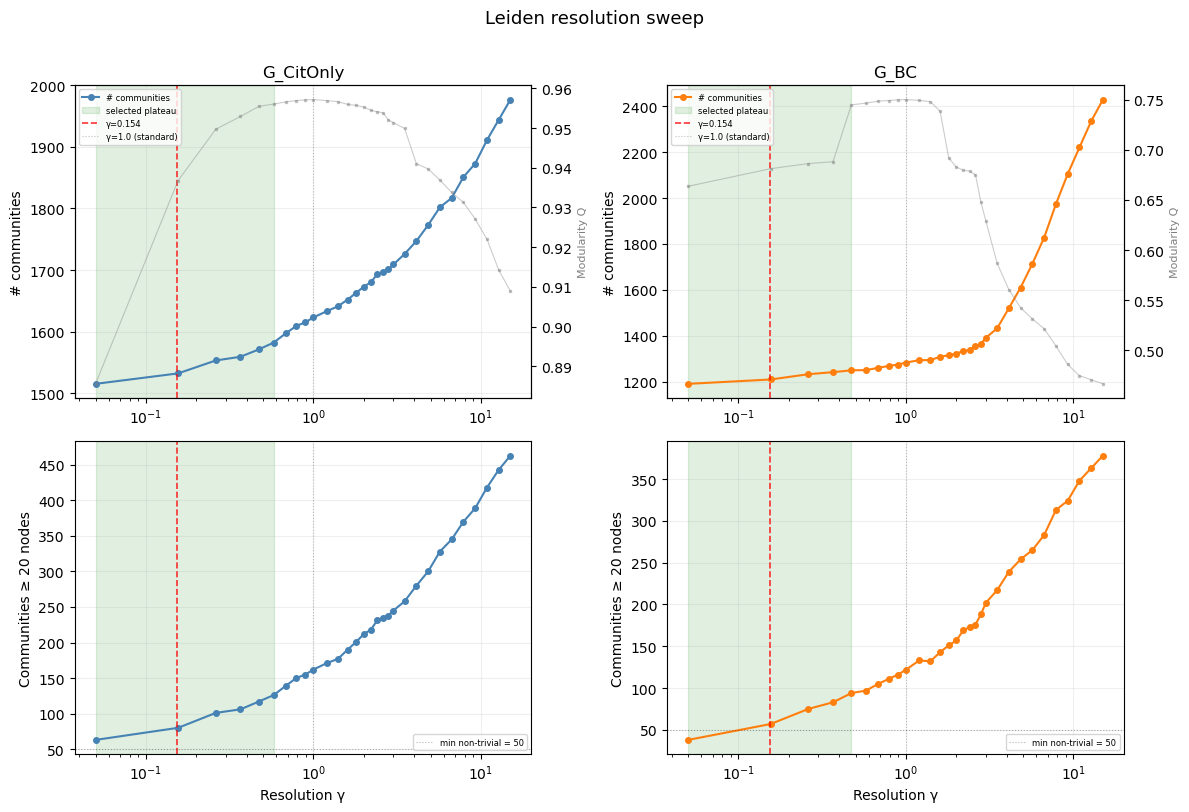

Plateau CitOnly: γ ∈ [0.0500, 0.5778]
Plateau BC:      γ ∈ [0.0500, 0.4722]
Common γ:        0.1537


In [20]:

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for col, (sweep, plateau, name, color) in enumerate([
    (sweep_cit, plateau_cit, 'G_CitOnly', 'steelblue'),
    (sweep_bc,  plateau_bc,  'G_BC',      'tab:orange'),
]):
    gammas   = np.array([g for g, _, _ in sweep])
    n_comms  = np.array([s['medoid_n_communities'] for _, _, s in sweep])
    mods     = np.array([s['medoid_modularity']    for _, _, s in sweep])
    med_sizes = np.array([np.median([len(c) for c in cl.communities]) for _, cl, _ in sweep])

    # Top row: n_communities + modularity
    ax = axes[0, col]
    ax.plot(gammas, n_comms, 'o-', color=color, ms=4, lw=1.5, label='# communities')
    ax.axvspan(plateau[0], plateau[1], alpha=0.12, color='green', label='selected plateau')
    ax.axvline(gamma_common, color='red', ls='--', lw=1.2, alpha=0.8, label=f'γ={gamma_common:.3f}')
    ax.axvline(1.0, color='grey', ls=':', lw=0.8, alpha=0.5, label='γ=1.0 (standard)')
    ax.set_xscale('log'); ax.set_ylabel('# communities')
    ax.set_title(name); ax.legend(fontsize=6, loc='upper left'); ax.grid(alpha=0.2)

    ax2 = ax.twinx()
    ax2.plot(gammas, mods, 's-', color='grey', ms=2, lw=0.8, alpha=0.4)
    ax2.set_ylabel('Modularity Q', color='grey', fontsize=8)

    # Bottom row: non-trivial communities (size >= 20)
    ax = axes[1, col]
    n_nt = np.array([sum(1 for c in cl.communities if len(c) >= 20) for _, cl, _ in sweep])
    ax.plot(gammas, n_nt, 'o-', color=color, ms=4, lw=1.5)
    ax.axvspan(plateau[0], plateau[1], alpha=0.12, color='green')
    ax.axvline(gamma_common, color='red', ls='--', lw=1.2, alpha=0.8)
    ax.axvline(1.0, color='grey', ls=':', lw=0.8, alpha=0.5)
    ax.axhline(50, color='black', ls=':', lw=0.8, alpha=0.3, label='min non-trivial = 50')
    ax.set_xscale('log'); ax.set_xlabel('Resolution γ')
    ax.set_ylabel('Communities ≥ 20 nodes'); ax.legend(fontsize=6); ax.grid(alpha=0.2)

plt.suptitle('Leiden resolution sweep', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/leiden_resolution_sweep.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Plateau CitOnly: γ ∈ [{plateau_cit[0]:.4f}, {plateau_cit[1]:.4f}]")
print(f"Plateau BC:      γ ∈ [{plateau_bc[0]:.4f}, {plateau_bc[1]:.4f}]")
print(f"Common γ:        {gamma_common:.4f}")

## Ensemble runs at selected resolution

In [21]:
# Leiden — G_CitOnly (undirected, γ common)
leiden_internal, leiden_internal_stats = run_leiden_ensemble(
    G_nx       = G_CitOnly_undir,
    graph_name = 'G_CitOnly',
    weights    = None,
    resolution = gamma_common,
    n_runs     = N_RUN
)

    Loaded: /home/francesco/Documents/SocialNetwork/socialNetworkAnalysisProject/notebooks/C_community_detection/output/leiden_G_CitOnly_g0.153655_r100.pkl
  Medoid #comms: 1533 | Q: 0.9386 | NMI mean: 0.9407


In [22]:
# Leiden — G_BC (weighted, γ from sweep)
leiden_combined, leiden_combined_stats = run_leiden_ensemble(
    G_nx       = G_BC,
    graph_name = 'G_BC',
    weights    = 'weight',
    resolution = gamma_common,
    n_runs     = N_RUN
)

    Loaded: /home/francesco/Documents/SocialNetwork/socialNetworkAnalysisProject/notebooks/C_community_detection/output/leiden_G_BC_g0.153655_r100.pkl
  Medoid #comms: 1210 | Q: 0.6813 | NMI mean: 0.9336


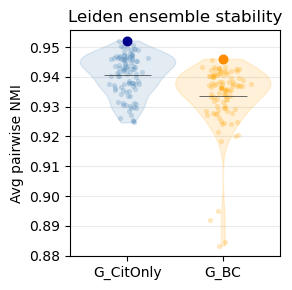

Internal:  μ=0.9407  σ=0.0067  medoid=0.9522
Combined:  μ=0.9336  σ=0.0110  medoid=0.9461


In [23]:
def plot_nmi_stability(stats_int, stats_comb):
    """Light side-by-side violin plots with jitter and medoid markers."""
    def avg_nmi(stats):
        m = stats['nmi_matrix']
        return (m.sum(axis=1) - 1) / (m.shape[0] - 1)

    nmi_int = avg_nmi(stats_int)
    nmi_comb = avg_nmi(stats_comb)

    fig, ax = plt.subplots(figsize=(3, 3))
    data = [nmi_int, nmi_comb]
    positions = [0, 1]

    vp = ax.violinplot(
        data,
        positions=positions,
        widths=1,
        showmeans=True,
        showmedians=False,
        showextrema=False,
    )
    for body, color in zip(vp['bodies'], ['steelblue', 'orange']):
        body.set_facecolor(color)
        body.set_edgecolor(color)
        body.set_alpha(0.15)
    vp['cmeans'].set_color('#333333')
    vp['cmeans'].set_linewidth(0.5)

    rng = np.random.default_rng(42)
    jitter_width = 0.1
    ax.scatter(
        rng.normal(positions[0], jitter_width, size=len(nmi_int)),
        nmi_int,
        s=14, color='steelblue', alpha=0.25, linewidths=0,
    )
    ax.scatter(
        rng.normal(positions[1], jitter_width, size=len(nmi_comb)),
        nmi_comb,
        s=14, color='orange', alpha=0.25, linewidths=0,
    )

    med_int = nmi_int[stats_int['medoid_idx']]
    med_comb = nmi_comb[stats_comb['medoid_idx']]
    ax.scatter(positions[0], med_int, s=55, color='darkblue', edgecolors='white', linewidths=0.2, zorder=2)
    ax.scatter(positions[1], med_comb, s=55, color='darkorange', edgecolors='white', linewidths=0.2, zorder=2)

    ax.set_xticks(positions)
    ax.set_xticklabels(['G_CitOnly', 'G_BC'])
    ax.set_ylabel('Avg pairwise NMI')
    ax.set_title('Leiden ensemble stability')
    ax.grid(axis='y', alpha=0.25)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

    print(f"Internal:  μ={nmi_int.mean():.4f}  σ={nmi_int.std():.4f}  medoid={med_int:.4f}")
    print(f"Combined:  μ={nmi_comb.mean():.4f}  σ={nmi_comb.std():.4f}  medoid={med_comb:.4f}")

plot_nmi_stability(leiden_internal_stats, leiden_combined_stats)

### Internal vs combined partition comparison

We align Leiden partitions on common nodes and compare them with NMI, ARI, VI, and best-match Jaccard.
Goal: measure which communities stay stable and which are reorganized after adding BC edges.

In [24]:
def _entropy(labels):
    _, counts = np.unique(labels, return_counts=True)
    p = counts / counts.sum()
    return -np.sum(p * np.log(p + 1e-12))

def variation_of_information(labels_a, labels_b):
    """VI = H(A) + H(B) - 2 * I(A,B)."""
    return (_entropy(labels_a) + _entropy(labels_b)
            - 2.0 * mutual_info_score(labels_a, labels_b))

def _partition_to_sets(partition, allowed_nodes=None, min_size=1):
    result = []
    for comm in partition.communities:
        s = set(comm)
        if allowed_nodes is not None:
            s &= allowed_nodes
        if len(s) >= min_size:
            result.append(s)
    return result

### Size distribution

A compact two-panel view highlights structural differences between `G_CitOnly` and `G_BC`:
- rank-size curve on log-log axes
- cumulative node coverage across ranked communities

In [25]:
def plot_size_distribution(partition_a, label_a, partition_b, label_b,
                           color_a='#2563EB', color_b='#F59E0B',
                           title='', thresholds=(0.50, 0.80, 0.95),
                           include_curves=False, save_path=None):
    """Rank-size plot + improved tabular summary with 10/50/80/95 coverage."""

    def _sizes(partition):
        sizes = sorted((len(c) for c in partition.communities), reverse=True)
        if not sizes:
            raise ValueError('Partition has no communities.')
        return np.asarray(sizes, dtype=float)

    def _summary(arr):
        cov = np.cumsum(arr) / arr.sum()
        summary = {
            'n': len(arr),
            'min': int(arr.min()),
            'max': int(arr.max()),
            'mean': float(arr.mean()),
            'median': float(np.median(arr)),
            'coverage': {k: float(arr[:min(k, len(arr))].sum() / arr.sum())
                         for k in (10, 50, 80, 95)},
            'nodes_for_thr': {
                thr: int(np.searchsorted(cov, thr, side='left') + 1)
                for thr in thresholds
            },
        }
        if include_curves:
            summary['cov'] = cov
        return summary, cov

    sizes_a = _sizes(partition_a)
    sizes_b = _sizes(partition_b)
    stats_a, cov_a = _summary(sizes_a)
    stats_b, cov_b = _summary(sizes_b)

    # Plot: rank-size (log-log)
    fig, ax = plt.subplots(figsize=(3, 3))
    rank_a = np.arange(1, len(sizes_a) + 1)
    rank_b = np.arange(1, len(sizes_b) + 1)
    
    ax.plot(rank_a, sizes_a, color=color_a, lw=1.5, alpha=0.9, label=label_a)
    ax.plot(rank_b, sizes_b, color=color_b, lw=1.5, alpha=0.9, label=label_b)
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    # y range between 1 and 25000, y range between 1 and max size
    ax.set_ylim(1, 25000)
    ax.set_xlabel('Community rank (log)', fontsize=11)
    ax.set_ylabel('Size in nodes (log)', fontsize=11)
    ax.grid(True, which='both', alpha=0.2)
    ax.set_facecolor('#FAFAFA')
    ax.legend(fontsize=9, loc='upper right', framealpha=0.95)
    
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


    # Table: size distribution summary
    table_data = []
    for label, stats in ((label_a, stats_a), (label_b, stats_b)):
        row = {
            'Graph': label,
            'n_comms': stats['n'],
            'min': stats['min'],
            'max': stats['max'],
            'mean': f"{stats['mean']:.1f}",
            'median': f"{stats['median']:.1f}",
            'cov_10': f"{stats['coverage'][10]:.1%}",
            'cov_50': f"{stats['coverage'][50]:.1%}",
            'cov_80': f"{stats['coverage'][80]:.1%}",
            'cov_95': f"{stats['coverage'][95]:.1%}",
            'k_50%': stats['nodes_for_thr'][0.50],
            'k_80%': stats['nodes_for_thr'][0.80],
            'k_95%': stats['nodes_for_thr'][0.95],
        }
        table_data.append(row)

    df_summary = pd.DataFrame(table_data)
    
    print("\nSIZE DISTRIBUTION SUMMARY")
    print("=" * 130)
    print(df_summary.to_string(index=False))
    print("=" * 130)
    print("\nLegend:")
    print("  n_comms: number of communities")
    print("  min/max/mean/median: community size statistics")
    print("  cov_K: fraction of nodes covered by top-K communities")
    print("  k_XX%: number of communities needed to reach XX% coverage")

    return {
        label_a: stats_a,
        label_b: stats_b,
    }


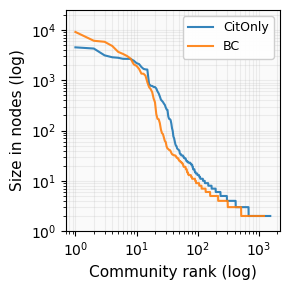


SIZE DISTRIBUTION SUMMARY
  Graph  n_comms  min  max mean median cov_10 cov_50 cov_80 cov_95  k_50%  k_80%  k_95%
CitOnly     1533    2 4520 35.9    2.0  54.9%  90.0%  91.5%  91.9%      9     22    352
     BC     1210    2 9145 47.6    2.0  74.1%  93.4%  94.3%  94.6%      5     13    124

Legend:
  n_comms: number of communities
  min/max/mean/median: community size statistics
  cov_K: fraction of nodes covered by top-K communities
  k_XX%: number of communities needed to reach XX% coverage


{'CitOnly': {'n': 1533,
  'min': 2,
  'max': 4520,
  'mean': 35.928245270711024,
  'median': 2.0,
  'coverage': {10: 0.5492755728239951,
   50: 0.9004684265950107,
   80: 0.9149569701151095,
   95: 0.9194415192999019},
  'nodes_for_thr': {0.5: 9, 0.8: 22, 0.95: 352}},
 'BC': {'n': 1210,
  'min': 2,
  'max': 9145,
  'mean': 47.60578512396694,
  'median': 2.0,
  'coverage': {10: 0.7405169869624846,
   50: 0.9343089769630054,
   80: 0.9432321233269101,
   95: 0.9459750360224294},
  'nodes_for_thr': {0.5: 5, 0.8: 13, 0.95: 124}}}

In [26]:
plot_size_distribution(
    leiden_internal, 'CitOnly',
    leiden_combined, 'BC',
    color_a='tab:blue', color_b='tab:orange',
    title='', save_path="./output/leiden_size_distribution.png"
)

In [27]:
_LEVEL_RE = {
    'macro': re.compile(r'^\d{2}\s'),
    'sub':   re.compile(r'^\d{4}\s'),
}

def parse_labels(val, level='sub'):
    """Split labels and optionally filter to macro/sub FOS levels."""
    if not val:
        return []
    parts = [p.strip() for p in str(val).split(';') if p.strip()]
    pattern = _LEVEL_RE.get(level)
    return [p for p in parts if pattern.match(p)] if pattern else parts

In [28]:
def compute_semantic_purity(clustering, G, attr='FOS', level='macro', min_size=10):
    """Weighted entropy and Gini inequality per community (filtered by min_size)."""
    def _gini_inequality(counts):
        """Gini inequality index: 1 = one class has everything, 0 = perfectly equal."""
        if len(counts) == 0:
            return 0.0
        s = np.sort(counts.astype(float))
        n = len(s)
        return (2 * np.sum(np.arange(1, n+1) * s)) / (n * s.sum()) - (n+1) / n

    entropies, ginis, sizes = [], [], []
    for comm in clustering.communities:
        if len(comm) < min_size:
            continue
        labels = []
        for node in comm:
            labels.extend(parse_labels(G.nodes[node].get(attr), level=level))
        if not labels:
            continue
        _, counts = np.unique(labels, return_counts=True)
        probs = counts / counts.sum()
        H = scipy_entropy(probs, base=2)
        H_max = np.log2(len(counts)) if len(counts) > 1 else 1.0
        entropies.append(H / H_max if H_max > 0 else 0.0)
        ginis.append(_gini_inequality(counts))
        sizes.append(len(comm))

    sizes = np.array(sizes)
    total = sizes.sum()
    return {
        'entropy': (np.array(entropies) * sizes).sum() / total,
        'gini_inequality': (np.array(ginis) * sizes).sum() / total,
        'n_comms': len(sizes),
    }


def print_purity_comparison(leiden_int, leiden_comb, G_int, G_comb, min_size=10):
    """Compare and print semantic purity: internal vs combined."""
    print("\n" + "=" * 80)
    print("SEMANTIC PURITY ANALYSIS")
    print("=" * 80)

    for key, attr, level in [('FOS_L2', 'FOS', 'macro'), ('FOS', 'FOS', 'sub'), ('SDG', 'SDG', 'all')]:
        p_int  = compute_semantic_purity(leiden_int,  G_int,  attr=attr, level=level, min_size=min_size)
        p_comb = compute_semantic_purity(leiden_comb, G_comb, attr=attr, level=level, min_size=min_size)

        de = p_comb['entropy'] - p_int['entropy']
        dg = p_comb['gini_inequality'] - p_int['gini_inequality']
        e_verdict = "WORSE" if de > 0.01 else ("BETTER" if de < -0.01 else "SAME")
        g_verdict = "BETTER" if dg > 0.01 else ("WORSE" if dg < -0.01 else "SAME")

        print(f"\n{key}:")
        print(f"  Internal  | Entropy: {p_int['entropy']:.4f} | Gini ineq.: {p_int['gini_inequality']:.4f} | Comms: {p_int['n_comms']}")
        print(f"  Combined  | Entropy: {p_comb['entropy']:.4f} | Gini ineq.: {p_comb['gini_inequality']:.4f} | Comms: {p_comb['n_comms']}")
        print(f"  Δ Combined vs Internal: Entropy {de:+.4f} ({e_verdict}) | Gini ineq. {dg:+.4f} ({g_verdict})")

    print("=" * 80)

print_purity_comparison(leiden_internal, leiden_combined, G_CitOnly_undir, G_BC)


SEMANTIC PURITY ANALYSIS

FOS_L2:
  Internal  | Entropy: 0.4137 | Gini ineq.: 0.6241 | Comms: 130
  Combined  | Entropy: 0.4192 | Gini ineq.: 0.6442 | Comms: 92
  Δ Combined vs Internal: Entropy +0.0055 (SAME) | Gini ineq. +0.0201 (BETTER)

FOS:
  Internal  | Entropy: 0.4923 | Gini ineq.: 0.7778 | Comms: 130
  Combined  | Entropy: 0.4787 | Gini ineq.: 0.8106 | Comms: 92
  Δ Combined vs Internal: Entropy -0.0135 (BETTER) | Gini ineq. +0.0328 (BETTER)

SDG:
  Internal  | Entropy: 0.5702 | Gini ineq.: 0.6995 | Comms: 122
  Combined  | Entropy: 0.5839 | Gini ineq.: 0.6952 | Comms: 89
  Δ Combined vs Internal: Entropy +0.0137 (WORSE) | Gini ineq. -0.0043 (SAME)


### Fate analysis - BC impact within Leiden

Each community in `leiden_internal` is classified by its outcome in `leiden_combined`.

| Fate | Rule | Interpretation |
|---|---|---|
| stable | best Jaccard >= 0.50 | community mostly preserved after BC |
| merged | >=2 internal communities map to one combined community | BC consolidates previously separated blocks |
| split | one internal community maps to >=2 combined communities | BC reveals latent substructure |
| dissolved | best Jaccard < 0.20 | no clear counterpart after BC |
| partial | otherwise | mixed reshaping dynamics |

Only communities with size >= 20 are analyzed to reduce micro-community noise.

Cross-domain merge: merged components have different dominant macro-FOS labels.

How to read the output:
- `merged` prevalence with high modularity indicates de-siloing without random mixing;
- `split` prevalence indicates finer thematic differentiation in the BC graph;
- cross-domain merges are high-value candidates for interdisciplinary convergence hypotheses.

In [29]:
def get_top_labels(comm, G, attr='FOS', level='sub', top_k=3):
    """Return top labels as 'Label (n%)' string."""
    counter = Counter()
    for node in comm:
        counter.update(parse_labels(G.nodes[node].get(attr), level=level))
    total = sum(counter.values())
    if not total:
        return 'N/A'
    return ' | '.join(f"{k} ({v/total:.0%})" for k, v in counter.most_common(top_k))


def classify_community_fates(part_a, part_b, G,
                              name_a='A', name_b='B',
                              stable_thr=0.5, dissolved_thr=0.20,
                              min_size=50, attr='FOS', level='sub'):
    """Classify each community in part_a by its fate in part_b."""
    common = ({n for c in part_a.communities for n in c}
              & {n for c in part_b.communities for n in c})
    a_sets = _partition_to_sets(part_a, common, min_size)
    b_sets = _partition_to_sets(part_b, common, min_size)

    b_to_a_groups = defaultdict(list)
    rows = []

    for a_id, A in enumerate(a_sets):
        overlap = {b_id: len(A & B) / len(A | B)
                   for b_id, B in enumerate(b_sets) if A & B}

        if not overlap:
            rows.append({'a_id': a_id, 'size_a': len(A),
                         'best_jacc': 0.0, 'best_b_id': None,
                         'n_b_touched': 0, 'top_b_frac': 0.0,
                         'top_fos': get_top_labels(A, G, attr=attr, level=level),
                         'fate': 'dissolved'})
            continue

        best_b = max(overlap, key=overlap.get)
        top_b_frac = len(A & b_sets[best_b]) / len(A)
        n_touched = sum(1 for v in overlap.values() if v > 0.05)
        b_to_a_groups[best_b].append(a_id)
        rows.append({'a_id': a_id, 'size_a': len(A),
                     'best_jacc': round(overlap[best_b], 4), 'best_b_id': best_b,
                     'n_b_touched': n_touched,
                     'top_b_frac': round(top_b_frac, 3),
                     'top_fos': get_top_labels(A, G, attr=attr, level=level),
                     'fate': '__pending__'})

    df = pd.DataFrame(rows)

    b_group_size = df['best_b_id'].map(
        lambda bid: len(b_to_a_groups[bid]) if bid is not None else 0
    )
    df['fate'] = np.select(
        [df['fate'] == 'dissolved',
         df['best_jacc'] >= stable_thr,
         b_group_size > 1,
         (df['n_b_touched'] >= 2) & (df['top_b_frac'] < 0.70),
         df['best_jacc'] < dissolved_thr],
        ['dissolved', 'stable', 'merged', 'split', 'dissolved'],
        default='partial',
    )

    merge_events = []
    for b_id, a_ids in b_to_a_groups.items():
        if len(a_ids) < 2:
            continue
        event_comms = [a_sets[i] for i in a_ids]
        fos_profiles = [get_top_labels(c, G, attr=attr, top_k=2, level=level)
                        for c in event_comms]
        b_fos = get_top_labels(b_sets[b_id], G, attr=attr, top_k=3, level=level)
        unique_dom = len({p.split(' | ')[0].split(' (')[0] for p in fos_profiles})
        merge_events.append({
            'b_id': b_id, 'b_size': len(b_sets[b_id]),
            'b_nodes': list(b_sets[b_id]),      # ← unica aggiunta
            'n_merged': len(a_ids), 'a_sizes': [len(c) for c in event_comms],
            'fos_profiles': fos_profiles, 'b_fos': b_fos,
            'cross_domain': unique_dom > 1,
        })
    merge_events.sort(key=lambda x: x['b_size'], reverse=True)

    map_a = {n: cid for cid, s in enumerate(a_sets) for n in s}
    map_b = {n: cid for cid, s in enumerate(b_sets) for n in s}
    common_nodes = sorted(set(map_a) & set(map_b))
    la = np.array([map_a[n] for n in common_nodes])
    lb = np.array([map_b[n] for n in common_nodes])
    nmi = normalized_mutual_info_score(la, lb, average_method='arithmetic')
    vi = variation_of_information(la, lb)

    print(f'\n{"="*60}')
    print(f'  Fate Analysis: {name_a} -> {name_b}')
    print(f'{"="*60}')
    print(f'  Communities analysed (>={min_size} nodes): {len(df)}')
    print(f'  NMI: {nmi:.4f}  |  VI: {vi:.4f}')
    for fate, grp in df.groupby('fate'):
        pct = len(grp) / len(df) * 100
        print(f'    {fate:<12s} {len(grp):>4d}  ({pct:5.1f}%)  {"#" * int(pct/2)}')
    n_cross = sum(e['cross_domain'] for e in merge_events)
    print(f'\n  Merge events: {len(merge_events)}  |  Cross-domain: {n_cross}')

    return df, merge_events, {'NMI': nmi, 'VI': vi}


def print_merge_report(merge_events, top_n=10):
    """Print top-N merge events with FOS profiles."""
    print(f'\n{"="*65}')
    print(f'  TOP {top_n} MERGE EVENTS  (components >= 50 nodes)')
    print(f'{"="*65}')
    for i, ev in enumerate(merge_events[:top_n]):
        tag = '[cross-domain]' if ev['cross_domain'] else '[same-domain]'
        print(f'\n  [{i+1}] {tag}  -  {ev["n_merged"]} comms -> 1  (merged size: {ev["b_size"]})')
        print(f'       Merged FOS: {ev["b_fos"]}')
        for j, (fos, sz) in enumerate(zip(ev['fos_profiles'], ev['a_sizes'])):
            print(f'         C{j+1} (n={sz:>5d}): {fos}')

In [30]:
df_fates_leiden, merge_events_leiden, global_leiden = classify_community_fates(
    part_a   = leiden_internal,
    part_b   = leiden_combined,
    G        = G_BC,
    name_a   = 'Leiden/Internal',
    name_b   = 'Leiden/Combined',
    attr     = 'FOS',
    level    = 'sub',
    min_size = MIN_COMM_SIZE,
)


  Fate Analysis: Leiden/Internal -> Leiden/Combined
  Communities analysed (>=20 nodes): 81
  NMI: 0.8032  |  VI: 1.2186
    merged         35  ( 43.2%)  #####################
    partial         1  (  1.2%)  
    stable         45  ( 55.6%)  ###########################

  Merge events: 16  |  Cross-domain: 12


In [31]:
print_merge_report(merge_events_leiden, top_n=20)


  TOP 20 MERGE EVENTS  (components >= 50 nodes)

  [1] [cross-domain]  -  7 comms -> 1  (merged size: 8719)
       Merged FOS: 0302 clinical medicine (57%) | 0301 basic medicine (26%) | 0303 health sciences (15%)
         C1 (n= 4520): 0302 clinical medicine (57%) | 0301 basic medicine (26%)
         C2 (n= 2099): 0302 clinical medicine (63%) | 0301 basic medicine (24%)
         C3 (n=  844): 0302 clinical medicine (61%) | 0301 basic medicine (25%)
         C4 (n=  734): 0302 clinical medicine (49%) | 0301 basic medicine (28%)
         C5 (n=  324): 0301 basic medicine (45%) | 0303 health sciences (33%)
         C6 (n=  169): 0302 clinical medicine (98%) | 0502 economics and business (1%)
         C7 (n=   27): 0403 veterinary science (59%) | 0302 clinical medicine (33%)

  [2] [cross-domain]  -  3 comms -> 1  (merged size: 5970)
       Merged FOS: 0302 clinical medicine (36%) | 0301 basic medicine (34%) | 0303 health sciences (22%)
         C1 (n= 3133): 0301 basic medicine (45%) | 0

## Gini permutation test — merge significance

For each merge event, test whether its FOS concentration is significantly higher
than expected from a random sample of the same size drawn from the corpus-wide
FOS distribution. This is a corpus-level null — shuffling labels *within* a merge
is a no-op since frequencies don't change.

In [32]:
# Build corpus-level FOS pool for null model
corpus_pool = build_corpus_fos_pool(G_BC, attr='FOS', level='sub')
print(f"Corpus FOS pool: {len(corpus_pool)} labels, {len(np.unique(corpus_pool))} unique")

# Build node → FOS L4 label dict
fos_labels_dict = {}
for nid, data in G_BC.nodes(data=True):
    fos = data.get('FOS', '')
    parts = [p.strip() for p in str(fos).split(';') if re.match(r'^\d{4}\s', p.strip())]
    fos_labels_dict[nid] = parts[0] if parts else ''

# Convert merge_events_leiden → format for validate_merges
# Uses b_nodes directly (NOT b_id index, which maps to filtered b_sets, not communities)
merges = []
for i, evt in enumerate(merge_events_leiden):
    merges.append({
        'name': f"M{i+1}",
        'node_ids': evt['b_nodes'],
    })

print(f"\nTesting {len(merges)} merge events:")
gini_results = validate_merges(merges, fos_labels_dict, corpus_pool)

sig_count = sum(1 for r in gini_results if r['significant'])
print(f"\n{sig_count}/{len(gini_results)} merges have significant concentration (p < 0.05)")

Corpus FOS pool: 63248 labels, 39 unique

Testing 16 merge events:
    Loaded: /home/francesco/Documents/SocialNetwork/socialNetworkAnalysisProject/notebooks/C_community_detection/output/gini_validation_16merges.pkl
  M1     | n= 8719 | Gini=0.475 (obs) vs 0.893±0.002 (null) | p=0.0000 | ✓ SIGNIFICANT
  M2     | n= 5970 | Gini=0.539 (obs) vs 0.893±0.002 (null) | p=0.0000 | ✓ SIGNIFICANT
  M3     | n= 5725 | Gini=0.725 (obs) vs 0.893±0.002 (null) | p=0.0000 | ✓ SIGNIFICANT
  M4     | n= 4768 | Gini=0.764 (obs) vs 0.893±0.002 (null) | p=0.0000 | ✓ SIGNIFICANT
  M5     | n= 3475 | Gini=0.645 (obs) vs 0.893±0.003 (null) | p=0.0000 | ✓ SIGNIFICANT
  M6     | n= 3139 | Gini=0.423 (obs) vs 0.893±0.003 (null) | p=0.0000 | ✓ SIGNIFICANT
  M7     | n= 2045 | Gini=0.126 (obs) vs 0.893±0.003 (null) | p=0.0000 | ✓ SIGNIFICANT
  M8     | n= 1882 | Gini=0.722 (obs) vs 0.893±0.004 (null) | p=0.0000 | ✓ SIGNIFICANT
  M9     | n= 1612 | Gini=0.797 (obs) vs 0.893±0.004 (null) | p=0.0000 | ✓ SIGNIFICANT
 